## Imports, loading data and preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
from sklearn.base import BaseEstimator
from sklearn.linear_model import LinearRegression, LogisticRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SequentialFeatureSelector, SelectKBest, SelectFromModel, mutual_info_classif, RFECV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, BaggingClassifier, BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from xgboost import XGBClassifier, XGBRegressor
from sklearn.svm import SVC, SVR

import optuna

import logging

from typing import Protocol, Any, cast, Literal, Callable
from dataclasses import dataclass, field

### Loading the dataset

In [2]:
df = pd.read_csv('zad2_wum_data_for_students.csv', sep=';')

display(df.head())
display(df.describe())

,Class,Output,Input1,Input2,Input3,Input4,Input5,Input6,Input7,Input8,...,Input391,Input392,Input393,Input394,Input395,Input396,Input397,Input398,Input399,Input400
0,0,0.800586,-0.002583,2.184037,-0.322008,1.621241,1.192444,-0.278356,-0.207366,0.735689,...,-2.140861,1.187660,0.345238,-0.844885,0.580007,-2.605781,-0.299471,0.711487,-0.753316,0.728763
1,0,2.168475,0.668637,1.373933,-0.476868,-0.724704,0.031162,-1.845921,0.784890,1.508526,...,-1.286120,-0.900044,-0.500399,-0.126421,-0.632233,-2.557419,0.056044,0.634774,-0.259835,0.106390
2,1,-1.210777,-0.681438,-0.544753,0.441346,-0.019906,-0.192135,-0.162510,-0.998777,0.686472,...,-0.391605,-0.190147,0.793746,-0.812737,-0.068228,-0.313143,2.564096,0.848355,0.180556,-1.525615
3,1,0.505678,-0.497957,0.720712,0.149120,0.019251,1.377850,0.981337,-0.846813,0.036790,...,-0.176734,-0.947351,-0.888601,1.509450,-0.501929,-0.554909,-0.104051,0.442150,-0.056644,1.447267
4,1,-10.281033,-1.178544,0.176941,1.112202,1.234189,0.999451,-0.773329,-0.811075,1.550537,...,-0.181325,0.198960,-0.697497,-0.836371,1.652071,0.974292,1.584071,-0.202352,1.362426,1.023857


,Class,Output,Input1,Input2,Input3,Input4,Input5,Input6,Input7,Input8,...,Input391,Input392,Input393,Input394,Input395,Input396,Input397,Input398,Input399,Input400
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.506500,0.106647,-0.005665,-0.016681,-0.005334,0.003488,0.002534,0.006839,-0.012273,-0.020030,...,-0.019331,0.029074,0.020895,-0.016766,-0.007556,0.010091,0.007851,0.012891,0.004650,-0.013988
std,0.500083,3.562855,0.999429,1.010284,0.991542,0.987569,0.999472,1.008721,1.005626,1.002895,...,0.994439,1.000463,0.988078,0.994856,0.983238,0.996567,0.987002,0.995252,0.999906,0.997836
min,0.000000,-12.384019,-4.040194,-3.119465,-2.978635,-3.667101,-3.466724,-3.230187,-3.686750,-2.971715,...,-4.003626,-3.415436,-3.233725,-3.292675,-3.572882,-3.416226,-2.804361,-3.384484,-3.493723,-3.369950
25%,0.000000,-2.310265,-0.652010,-0.704739,-0.649305,-0.657961,-0.662386,-0.656393,-0.670924,-0.702121,...,-0.682235,-0.637035,-0.644477,-0.687878,-0.648976,-0.720322,-0.670621,-0.644547,-0.665419,-0.690380
50%,1.000000,0.140658,0.001009,-0.058297,0.025890,0.000425,-0.037171,0.020573,0.000160,-0.006156,...,0.013317,0.027436,0.019631,-0.009518,-0.006203,0.051022,0.029848,0.042120,0.022766,-0.012325
75%,1.000000,2.435991,0.639342,0.581323,0.676253,0.648669,0.684755,0.687058,0.664702,0.668752,...,0.642293,0.732498,0.679480,0.678636,0.659516,0.777529,0.660940,0.700344,0.680525,0.674120
max,1.000000,11.676146,3.370270,5.357014,3.674250,3.872662,3.507387,3.038254,3.764414,3.466016,...,3.601507,4.390463,3.150263,3.123106,3.294423,2.962170,3.069878,3.331561,3.054563,3.129274


### Preparation
1. checking for missing data,
2. defining my variables and classes.

In [3]:
print("====== TYPES ======")
display(df.dtypes)
print("====== DESCRIBE ======")
display(df.describe())

print("====== UNIQUE VALUES ======")
display(df["Class"].unique())

print("====== NULL VALUES ======")
display(df.isnull().sum())

print("====== SCALE CHECKING ======")
for column in df.columns:
  if column == "Class" or column == "Output":
    continue
  if df[column].mean() > 0.9:
    print(f"Column '{column}' has a mean value of {df[column].mean():.4f}, which is greater than 0.9. Consider removing it.")
  if df[column].std() - 1 > 0.1:
    print(f"Column '{column}' has a standard deviation of {df[column].std():.4f}, which is significantly different from 1. Consider normalizing it.")
print("====== END OF SCALE CHECKING ======")


====== TYPES ======


Class         int64
Output      float64
Input1      float64
Input2      float64
Input3      float64
             ...   
Input396    float64
Input397    float64
Input398    float64
Input399    float64
Input400    float64
Length: 402, dtype: object

====== DESCRIBE ======


,Class,Output,Input1,Input2,Input3,Input4,Input5,Input6,Input7,Input8,...,Input391,Input392,Input393,Input394,Input395,Input396,Input397,Input398,Input399,Input400
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.506500,0.106647,-0.005665,-0.016681,-0.005334,0.003488,0.002534,0.006839,-0.012273,-0.020030,...,-0.019331,0.029074,0.020895,-0.016766,-0.007556,0.010091,0.007851,0.012891,0.004650,-0.013988
std,0.500083,3.562855,0.999429,1.010284,0.991542,0.987569,0.999472,1.008721,1.005626,1.002895,...,0.994439,1.000463,0.988078,0.994856,0.983238,0.996567,0.987002,0.995252,0.999906,0.997836
min,0.000000,-12.384019,-4.040194,-3.119465,-2.978635,-3.667101,-3.466724,-3.230187,-3.686750,-2.971715,...,-4.003626,-3.415436,-3.233725,-3.292675,-3.572882,-3.416226,-2.804361,-3.384484,-3.493723,-3.369950
25%,0.000000,-2.310265,-0.652010,-0.704739,-0.649305,-0.657961,-0.662386,-0.656393,-0.670924,-0.702121,...,-0.682235,-0.637035,-0.644477,-0.687878,-0.648976,-0.720322,-0.670621,-0.644547,-0.665419,-0.690380
50%,1.000000,0.140658,0.001009,-0.058297,0.025890,0.000425,-0.037171,0.020573,0.000160,-0.006156,...,0.013317,0.027436,0.019631,-0.009518,-0.006203,0.051022,0.029848,0.042120,0.022766,-0.012325
75%,1.000000,2.435991,0.639342,0.581323,0.676253,0.648669,0.684755,0.687058,0.664702,0.668752,...,0.642293,0.732498,0.679480,0.678636,0.659516,0.777529,0.660940,0.700344,0.680525,0.674120
max,1.000000,11.676146,3.370270,5.357014,3.674250,3.872662,3.507387,3.038254,3.764414,3.466016,...,3.601507,4.390463,3.150263,3.123106,3.294423,2.962170,3.069878,3.331561,3.054563,3.129274


====== UNIQUE VALUES ======


array([0, 1])

====== NULL VALUES ======


Class       0
Output      0
Input1      0
Input2      0
Input3      0
           ..
Input396    0
Input397    0
Input398    0
Input399    0
Input400    0
Length: 402, dtype: int64

====== SCALE CHECKING ======
====== END OF SCALE CHECKING ======


As we can see above, no values are missing and all values are scaled properly.
(`std` $=1$, `mean` $=0$)

Below I introduce the main class used in my notebook - `model evaluator`.

It will perform `train_test_split` as well as register all
used models, choose the best ones and asses their performance on
`test set`.

I will use class `Model Evaluator` to keep track of checked models and their performance.

In [4]:
from xgboost import cv


CLASSIFICATION_COLUMN = 'Class'
REGRESSION_COLUMN = 'Output'
SEED = 11007
CV_FOLDS = 5
TEST_SET_SIZE = 0.1

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

class ModelProtocol(Protocol):
  ''' Protocol for machine learning models that require fit and predict methods.'''
  def fit(self, X: Any, y: Any, **fit_params: Any) -> None: ...
  def predict(self, X: Any, **predict_params: Any) -> Any: ...

def cast_to_model_protocol(model: Any) -> ModelProtocol:
  if not hasattr(model, 'fit') or not callable(getattr(model, 'fit')):
    raise TypeError(f"Model {model} does not have a fit method")
  if not hasattr(model, 'predict') or not callable(getattr(model, 'predict')):
    raise TypeError(f"Model {model} does not have a predict method")
  return cast(ModelProtocol, model)

@dataclass
class ModelResult:
  ''' 
  Represents the results of evaluating a machine learning model,
  including its name, instance, whether it's for classification
  or regression, and its performance metrics.
  '''
  model_name: str
  model_instance: ModelProtocol
  is_classification: bool
  metrics: dict[str, Any] = field(default_factory=dict)
  X_train: Any = None
  y_train: Any = None

  def __post_init__(self):
    self.estimator = cast(BaseEstimator, self.model_instance)
    
    if self.is_classification:
      stratified_cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
      accuracy = cross_val_score(self.estimator, self.X_train,
                                self.y_train, cv=stratified_cv, scoring='accuracy')
      self.metrics['accuracy_score'] = float(accuracy.mean())
    else:
      cv_strategy = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
      scoring_metrics = ['neg_mean_squared_error', 'r2']

      scores = cross_validate(self.estimator, self.X_train, self.y_train,
                              cv=cv_strategy, scoring=scoring_metrics)
      
      self.metrics['R2_score'] = float(scores['test_r2'].mean())
      self.metrics['MSE'] = -float(scores['test_neg_mean_squared_error'].mean())


class ModelEvaluator :
  def __init__(self, df: pd.DataFrame) -> None:
    '''
    Initializes the ModelEvaluator with the provided DataFrame.
    It splits the data into training and test sets for both classification
    and regression tasks.
    '''
    self._regression_results: dict[str, ModelResult] = {}
    self._classification_results: dict[str, ModelResult] = {}

    self._X = df.drop(columns=[CLASSIFICATION_COLUMN, REGRESSION_COLUMN])
    self._y_class = df[CLASSIFICATION_COLUMN]
    self._y_regr = df[REGRESSION_COLUMN]

    index_train, index_test = train_test_split(df.index, test_size=TEST_SET_SIZE, random_state=SEED)
    self._X_train, self._X_test             = self._X.iloc[index_train], self._X.iloc[index_test]
    self._y_train_class, self._y_test_class = self._y_class.iloc[index_train], self._y_class.iloc[index_test]
    self._y_train_reg, self._y_test_reg     = self._y_regr.iloc[index_train], self._y_regr.iloc[index_test]
  
  def display_data(self, n_dims: int) -> None:
    ''' Displays a PCA visualization of the dataset in either 2D or 3D.'''

    if n_dims not in (2, 3):
      logger.warning(f"Unsupported number of dimensions for visualization: {n_dims}. Only 2D and 3D are supported.")
      return
    
    X_pca = PCA(n_components=n_dims).fit_transform(self._X)

    df_pca = pd.DataFrame(data=X_pca, columns=[f'PC{i+1}' for i in range(n_dims)])
    df_pca['Class'] = self._y_class.astype(str).values

    if n_dims == 2:
      fig = px.scatter(df_pca, x='PC1', y='PC2', color='Class')
      fig.update_layout(title='PCA of Dataset (2D)')
      fig.show()
    elif n_dims == 3:
      fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3', color='Class')
      fig.update_layout(title='PCA of Dataset (3D)')
    
      fig.update_traces(marker=dict(size=4))
      fig.show()

  def create_pipeline(self, model: Any, use_pca: bool = False,
                    pca_components: int = 5, use_seq_selector: bool = False,
                    feature_sel_dir: Literal["forward", "backward"] = "forward",
                    features_to_select: float | Literal["auto"] = "auto",
                    poly_degree: int = 1) -> Pipeline:
    '''
    Creates a machine learning model pipeline with optional PCA,
    polynomial features, and sequential feature selection.
    '''
    
    steps: list[tuple[str, Any]] = []

    steps.append(('scaler', StandardScaler()))  

    if poly_degree > 1:
      steps.append(('poly', PolynomialFeatures(degree=poly_degree, include_bias=False)))

    if use_pca:
      steps.append(('pca', PCA(n_components=pca_components)))

    if use_seq_selector:
      steps.append(('selector', SequentialFeatureSelector(estimator=model, n_features_to_select=features_to_select, direction=feature_sel_dir)))

    steps.append(('estimator', model))
    return Pipeline(steps)
  
  def assess_on_training_data(self, model_name: str, model: ModelProtocol,
                             is_classification: bool) -> None:
    '''
    Evaluates a given model on the training data and returns a ModelResult instance
    containing the performance metrics.
    '''
    logger.info(f"Assessing model on training data: {model_name}")
    y_train = self._y_train_class if is_classification else self._y_train_reg

    model.fit(self._X_train, y_train)
    if is_classification:
      y_pred = model.predict(self._X_train)
      acc = accuracy_score(y_train, y_pred)
      metrics = {'accuracy_score': acc}
      logger.info(f"Model {model_name} assessed on training data with metrics:\n{metrics}\n")
    else:
      y_pred = model.predict(self._X_train)
      mse = mean_squared_error(y_train, y_pred)
      r2 = r2_score(y_train, y_pred)
      metrics = {'R2_score': r2, 'MSE': mse}
      logger.info(f"Model {model_name} assessed on training data with metrics:\n{metrics}\n")

  def evaluate_model(self, model_name: str, model: ModelProtocol,
                     is_classification: bool) -> None:
    '''
    Evaluates a given model using cross-validation (using cv=CV_FOLDS)
    on the training data and stores the results.
    Optionally, a custom training dataset can be provided.
    Assessing model is done in costruction of corresponding ModelResult dataclass.
    '''

    logger.info(f"Evaluating model: {model_name}")
    y_train = self._y_train_class if is_classification else self._y_train_reg

    result = ModelResult(
      model_name=model_name,
      model_instance=model,
      is_classification=is_classification,
      X_train=self._X_train,
      y_train=y_train
    )
    if is_classification:
      self._classification_results[model_name] = result
    else:
      self._regression_results[model_name] = result
    logger.info(f"Model {model_name} evaluated successfully with metrics:\n{result.metrics}\n")

  def evaluate_on_test_set(self, model_name: str, is_classification: bool) -> None:
    ''' Evaluates the specified model on the test set and logs the performance metrics.'''

    logger.info(f"Evaluating model on test set: {model_name}")
    
    if is_classification:
      result = self._classification_results.get(model_name)
      if not result:
        logger.error(f"Model {model_name} not found in classification results")
        return
      y_test = self._y_test_class
    else:
      result = self._regression_results.get(model_name)
      if not result:
        logger.error(f"Model {model_name} not found in regression results")
        return
      y_test = self._y_test_reg

    model_instance = result.model_instance
    model_instance.fit(result.X_train, result.y_train)

    y_pred = model_instance.predict(self._X_test)

    if is_classification:
      acc = accuracy_score(y_test, y_pred)
      report = classification_report(y_test, y_pred)
      conf_matrix = confusion_matrix(y_test, y_pred)
      logger.info(f"""Test set accuracy for {model_name}: {acc:.4f}\n
                      Classification Report:\n{report}\n
                      Confusion Matrix:\n{conf_matrix}\n""")
    else:
      mse = mean_squared_error(y_test, y_pred)
      r2 = r2_score(y_test, y_pred)
      logger.info(f"""Test set MSE for {model_name}: {mse:.4f}\n
                      R2 Score: {r2:.4f}\n""")
  def evaluate_on_validation_data(self, model_name: str, X_val: Any, y_val: Any, is_classification: bool) -> None:
    ''' Evaluates the specified model on a custom validation dataset and logs the performance metrics.'''

    logger.info(f"Evaluating model on validation data: {model_name}")
    
    if is_classification:
      result = self._classification_results.get(model_name)
      if not result:
        logger.error(f"Model {model_name} not found in classification results")
        return
    else:
      result = self._regression_results.get(model_name)
      if not result:
        logger.error(f"Model {model_name} not found in regression results")
        return

    model_instance = result.model_instance
    model_instance.fit(result.X_train, result.y_train)

    y_pred = model_instance.predict(X_val)

    if is_classification:
      acc = accuracy_score(y_val, y_pred)
      report = classification_report(y_val, y_pred)
      conf_matrix = confusion_matrix(y_val, y_pred)
      logger.info(f"""Validation set accuracy for {model_name}: {acc:.4f}\n
                      Classification Report:\n{report}\n
                      Confusion Matrix:\n{conf_matrix}\n""")
    else:
      mse = mean_squared_error(y_val, y_pred)
      r2 = r2_score(y_val, y_pred)
      logger.info(f"""Validation set MSE for {model_name}: {mse:.4f}\n
                      R2 Score: {r2:.4f}\n""")

  @property
  def results_classification(self) -> dict[str, ModelResult]:
    return self._classification_results
  
  @property
  def results_regression(self) -> dict[str, ModelResult]:
    return self._regression_results

  def get_best_classification_model(self) -> ModelResult | None:
    '''
    Returns the best classification model based on accuracy score,
    or None if no models have been evaluated.
    '''
    if not self._classification_results:
      return None
    self.best_classification_model = max(self._classification_results.values(), key=lambda r: r.metrics['accuracy_score'])
    return self.best_classification_model

  def get_best_regression_model(self) -> ModelResult | None:
    '''
    Returns the best regression model based on R2 score,
    or None if no models have been evaluated.
    '''
    if not self._regression_results:
      return None
    self.best_regression_model = max(self._regression_results.values(), key=lambda r: r.metrics['R2_score'])
    return self.best_regression_model

model_evaluator = ModelEvaluator(df)

model_evaluator.display_data(n_dims=2)
model_evaluator.display_data(n_dims=3)

Above I ilustrated `train set` in $2D$ and $3D$ using `PCA` with division by classes.

As we can see, it has more complex nature, and definitely more features than $3$
should be used. 

One can observe in $3D$ that some structure emerges: `red` dots are visibly
more centered and form a thick hyperplane. 

## TASK 1

Below I build *baseline* models: `Linear Regression` and `Logistic Regression`,
no preprocessing or feature selection involved.

In [5]:
linear_regression, linear_regression_str = LinearRegression(), "raw-linear-regression"
logistic_regression, logistic_regression_str = LogisticRegression(), "raw-logistic-regression"

model_evaluator.assess_on_training_data(linear_regression_str, cast_to_model_protocol(linear_regression), is_classification=False)
model_evaluator.evaluate_model(linear_regression_str, cast_to_model_protocol(LinearRegression()), is_classification=False)

model_evaluator.assess_on_training_data(logistic_regression_str, cast_to_model_protocol(logistic_regression), is_classification=True)
model_evaluator.evaluate_model(logistic_regression_str, cast_to_model_protocol(LogisticRegression()), is_classification=True)

2026-05-29 23:32:36,021 - INFO - Assessing model on training data: raw-linear-regression
2026-05-29 23:32:36,240 - INFO - Model raw-linear-regression assessed on training data with metrics:
{'R2_score': 0.6218985558681476, 'MSE': 4.846064022541106}

2026-05-29 23:32:36,241 - INFO - Evaluating model: raw-linear-regression
2026-05-29 23:32:36,850 - INFO - Model raw-linear-regression evaluated successfully with metrics:
{'R2_score': 0.34358550772997026, 'MSE': 8.341291216999409}

2026-05-29 23:32:36,852 - INFO - Assessing model on training data: raw-logistic-regression
2026-05-29 23:32:37,225 - INFO - Model raw-logistic-regression assessed on training data with metrics:
{'accuracy_score': 0.7172222222222222}

2026-05-29 23:32:37,228 - INFO - Evaluating model: raw-logistic-regression
2026-05-29 23:32:40,131 - INFO - Model raw-logistic-regression evaluated successfully with metrics:
{'accuracy_score': 0.5227777777777778}



As we can see:
1. `Linear Regression` and `Logistic Regression` have solid results when trained 
on `train set`.
(having in memory $0.8$ for *accuracy* and $0.5$ for $R^2$ which are said as possible)

2. Their ability to generalize beyond training data is weak - 
in the case of `regression` there is $\sim 50\%$ decline,
by `classification` it is also significat: $\sim 25\%$.

3. It is clear that more advanced methods are required (or some preprocessing).

## Exploratory data analisys

### Calculating corelation matrix

Counting corelation (normed covariance) between variables...


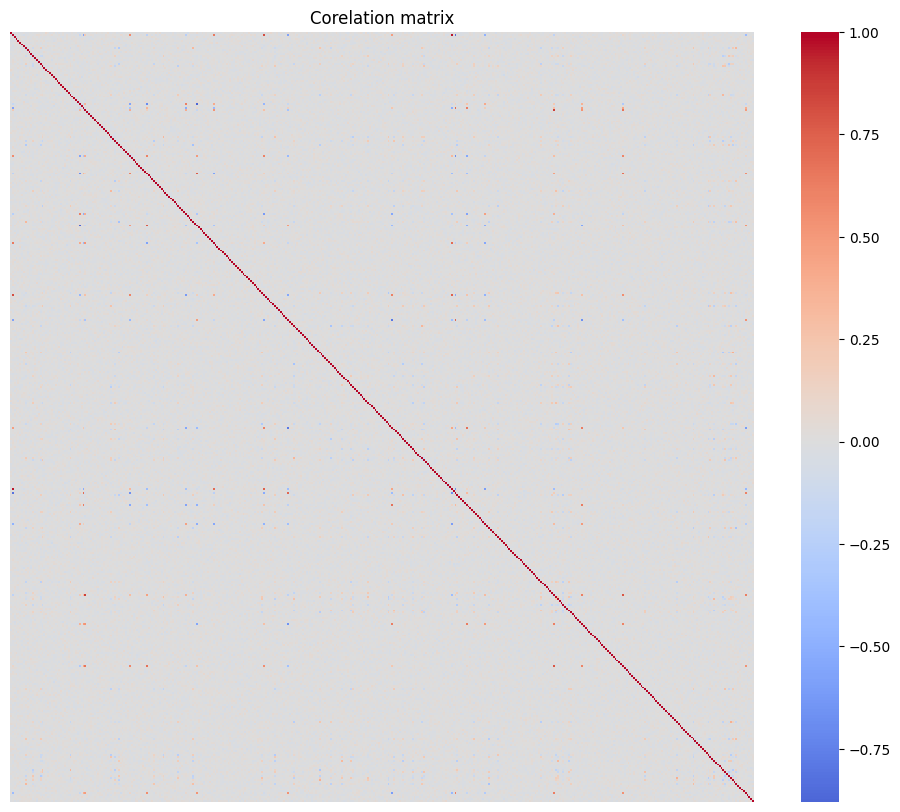

In [6]:
print("Counting corelation (normed covariance) between variables...")

X_features = model_evaluator._X_train
corr_matrix = X_features.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            center=0, 
            xticklabels=False,
            yticklabels=False)
plt.title("Corelation matrix")
plt.show()

My first guess is to look for corelation between the data.

It is clear that `noise` will not be corellated with **important**
features. Moreover **important** features may be somewhat corallated.

The matrix above suggests the following:
**most of the features are noise, while only small percentage of them are important**.

Let's see how it looks:

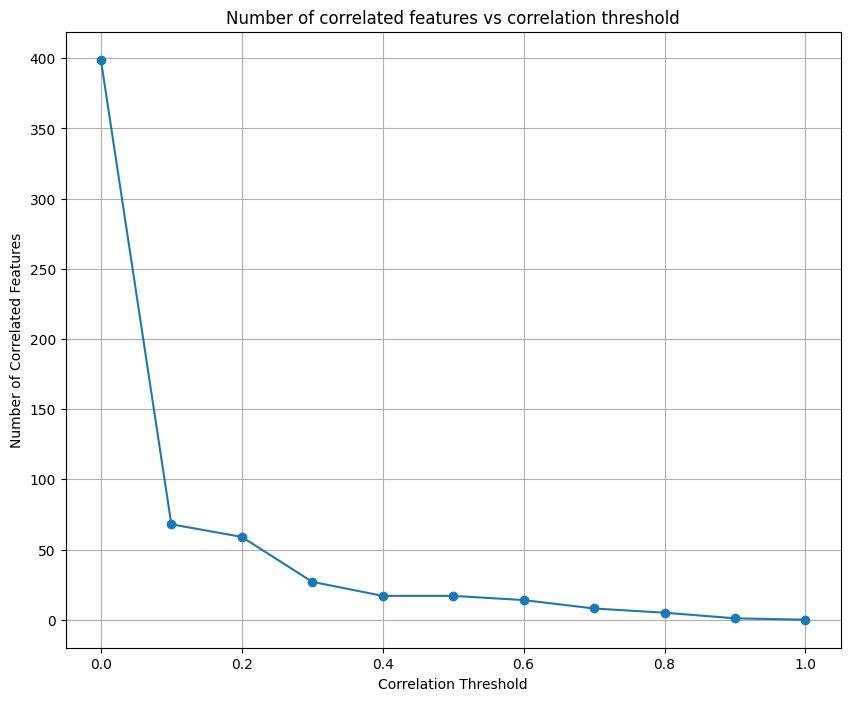

In [7]:
# W take bottom triangle of the matrix without diagonal (ones).
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))


thresholds = np.arange(0.0, 1.1, 0.1)
correlation_vars_by_threshold = {}
for threshold in thresholds:
  corr_vars = [column for column in upper_tri.columns if any(upper_tri[column].abs() > threshold)]
  correlation_vars_by_threshold[threshold] = corr_vars

plt.figure(figsize=(10, 8))
plt.plot(thresholds, [len(correlation_vars_by_threshold[t]) for t in thresholds], marker='o')
plt.title("Number of correlated features vs correlation threshold")
plt.xlabel("Correlation Threshold")
plt.ylabel("Number of Correlated Features")
plt.grid()
plt.show()

As we can see, $\sim 250$ features are not correlated at all.

This means feature selection will be the *key* here.
I procede with choosing features that correspond to `threshold` $= 0.3$.

In [8]:
selected_threshold = 0.3

selected_key = min(correlation_vars_by_threshold.keys(), key=lambda k: abs(float(k) - selected_threshold))
selected_cols = correlation_vars_by_threshold[selected_key]
print(f"Identified {len(selected_cols)} correlated features (threshold {selected_threshold}).")
print("These are:", selected_cols)

select_columns = ColumnTransformer(
    transformers=[
        ('select', 'passthrough', selected_cols)
    ],
    remainder='drop'
)

X_sel_train = model_evaluator._X_train[selected_cols]

Identified 27 correlated features (threshold 0.3).
These are: ['Input40', 'Input41', 'Input65', 'Input74', 'Input83', 'Input95', 'Input99', 'Input101', 'Input110', 'Input137', 'Input150', 'Input173', 'Input206', 'Input222', 'Input238', 'Input240', 'Input246', 'Input256', 'Input293', 'Input308', 'Input330', 'Input379', 'Input384', 'Input388', 'Input389', 'Input391', 'Input396']


In [9]:
def run_optuna_cv(
    make_pipeline: Callable[[optuna.Trial], Pipeline],
    X: pd.DataFrame,
    y: pd.Series,
    *,
    scoring: str,
    n_trials: int = 50,
    n_splits: int = 5,
    seed: int = 42,
    is_classification: bool = True,
    study_name: str | None = None,
    direction: str = "maximize",
    fit_best: bool = False,
    n_jobs: int = -1
 ):
    """
    Run Optuna with cross-validation and return the study and best pipeline.
    """
    def objective(trial: optuna.Trial) -> float:
        pipeline = make_pipeline(trial)
        if is_classification:
            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        else:
            cv = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring)
        return float(np.mean(scores))

    study = optuna.create_study(direction=direction, study_name=study_name)
    study.optimize(objective, n_trials=n_trials, n_jobs=n_jobs)

    best_pipeline = make_pipeline(cast(optuna.Trial, optuna.trial.FixedTrial(study.best_params)))
    if fit_best:
        best_pipeline.fit(X, y)

    return study, best_pipeline

## TASK 2 - more advanced classification

### Basic tree-based methods

In [ ]:
N_ESTIMATORS = 50
MAX_DEPTH = 5
LEARNING_RATE = 0.01

N_TRIALS = 60
N_JOBS = 1

rf_model = RandomForestClassifier(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH, random_state=SEED)
rf_pipeline = model_evaluator.create_pipeline(rf_model)
model_evaluator.evaluate_model("raw-random-forest", cast_to_model_protocol(rf_pipeline), is_classification=True)

bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=MAX_DEPTH), n_estimators=N_ESTIMATORS, random_state=SEED)
bagging_pipeline = model_evaluator.create_pipeline(bagging_model)
model_evaluator.evaluate_model("raw-bagging-classifier", cast_to_model_protocol(bagging_pipeline), is_classification=True)

gbm_model = GradientBoostingClassifier(n_estimators=N_ESTIMATORS, learning_rate=LEARNING_RATE, max_depth=3, random_state=SEED)
gbm_pipeline = model_evaluator.create_pipeline(gbm_model)
model_evaluator.evaluate_model("raw-gradient-boosting", cast_to_model_protocol(gbm_pipeline), is_classification=True)

2026-05-29 23:32:41,854 - INFO - Evaluating model: raw-random-forest
2026-05-29 23:32:44,973 - INFO - Model raw-random-forest evaluated successfully with metrics:
{'accuracy_score': 0.6494444444444445}

2026-05-29 23:32:44,974 - INFO - Evaluating model: raw-bagging-classifier


### XGBoosting + selected columns via corelation matrix

In [ ]:
%%time

def make_xgb_pipeline(trial: optuna.Trial) -> Pipeline:
  xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 7)
  xgb_lr = trial.suggest_float('xgb_lr', 0.01, 0.3, log=True)
  xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 300)
  xgb_min_child_weight = trial.suggest_int('xgb_min_child_weight', 1, 10)
  xgb_colsample_bytree = trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0)

  return Pipeline([
    ('column_selector', select_columns),
    ('classifier', XGBClassifier(
      max_depth=xgb_max_depth,
      learning_rate=xgb_lr,
      n_estimators=xgb_n_estimators,
      min_child_weight=xgb_min_child_weight,
      colsample_bytree=xgb_colsample_bytree,
      eval_metric='logloss',
      tree_method='hist',
      n_jobs=1,
      random_state=SEED
    ))
  ])

# --- OPTUNA ---
study_clf, best_pipeline_xgb_selected_cols = run_optuna_cv(
  make_pipeline=make_xgb_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_class,
  scoring='accuracy',
  n_trials=N_TRIALS,
  is_classification=True,
  study_name="XGB Hyperparameter Optimization",
  direction="maximize",
  n_jobs=N_JOBS
)
xgb_sel_cols_str = "optimized-xgboost with selected columns"

print("Best params:", study_clf.best_params)
print("Best accuracy:", study_clf.best_value)

model_evaluator.assess_on_training_data(xgb_sel_cols_str, cast_to_model_protocol(best_pipeline_xgb_selected_cols), is_classification=True)
model_evaluator.evaluate_model(xgb_sel_cols_str, cast_to_model_protocol(best_pipeline_xgb_selected_cols), is_classification=True)

### XGBoosting with feature selector: SelectKBest(`mutual_info_classif`)

In [ ]:
%%time

def make_xgb_pipeline_full(trial: optuna.Trial) -> Pipeline:
  k_param = trial.suggest_int('k_features', 10, 60)

  xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 7)
  xgb_lr = trial.suggest_float('xgb_lr', 0.01, 0.3, log=True)
  xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 300)

  xgb_min_child_weight = trial.suggest_int('xgb_min_child_weight', 1, 10)
  xgb_colsample_bytree = trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0)

  return Pipeline([
    ('feature_selection', SelectKBest(score_func=mutual_info_classif, k=k_param)),
    ('classifier', XGBClassifier(
      max_depth=xgb_max_depth,
      learning_rate=xgb_lr,
      n_estimators=xgb_n_estimators,
      min_child_weight=xgb_min_child_weight,
      colsample_bytree=xgb_colsample_bytree,
      eval_metric='logloss',
      tree_method='hist',
      n_jobs=1,
      random_state=SEED
    ))
  ])

# --- OPTUNA ---
study_clf, best_pipeline_xgb_full = run_optuna_cv(
  make_pipeline=make_xgb_pipeline_full,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_class,
  scoring='accuracy',
  n_trials=N_TRIALS,
  is_classification=True,
  n_jobs=N_JOBS,
  study_name="XGB Hyperparameter Optimization with Full Feature Selection",
)
xgb_full_str = "optimized-xgboost with full feature selection"

print("Best params:", study_clf.best_params)
print("Best accuracy:", study_clf.best_value)

model_evaluator.assess_on_training_data(xgb_full_str, cast_to_model_protocol(best_pipeline_xgb_full), is_classification=True)
model_evaluator.evaluate_model(xgb_full_str, cast_to_model_protocol(best_pipeline_xgb_full), is_classification=True)

### XGBoosting + column selection + feature selection with RF

In [ ]:
%%time

def make_pipeline_xgb_rf(trial: optuna.Trial) -> Pipeline:
  threshold_param = trial.suggest_categorical('rf_threshold',
        ['0.1*mean', '0.25*mean', '0.5*mean', 'mean', '1.25*mean', '1.5*mean'])
    
  xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 7)
  xgb_lr = trial.suggest_float('xgb_lr', 0.01, 0.2, log=True)
  xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 300)

  xgb_min_child_weight = trial.suggest_int('xgb_min_child_weight', 1, 10)
  xgb_colsample_bytree = trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0)
    
  return Pipeline([
    ("column_selector" , select_columns),
    ('feature_selection', SelectFromModel(
      RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42, n_jobs=1),
      threshold=threshold_param
    )),
    ('classifier', XGBClassifier(
      max_depth=xgb_max_depth,
      learning_rate=xgb_lr,
      n_estimators=xgb_n_estimators,
      min_child_weight=xgb_min_child_weight,
      colsample_bytree=xgb_colsample_bytree,
      eval_metric='logloss',
      tree_method='hist',
      n_jobs=1,
      random_state=SEED
    ))
  ])

# --- OPTUNA ---
study_clf, best_pipeline_xgb_full = run_optuna_cv(
  make_pipeline=make_pipeline_xgb_rf,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_class,
  scoring='accuracy',
  n_trials=N_TRIALS,
  is_classification=True,
  n_jobs=N_JOBS,
  study_name="XGB Hyperparameter Optimization with column selection and RF feature selection",
)
xgb_rf_col = "optimized-xgboost with RF and column selection"

print("Best params:", study_clf.best_params)
print("Best accuracy:", study_clf.best_value)

model_evaluator.assess_on_training_data(xgb_rf_col, cast_to_model_protocol(best_pipeline_xgb_full), is_classification=True)
model_evaluator.evaluate_model(xgb_rf_col, cast_to_model_protocol(best_pipeline_xgb_full), is_classification=True)

### XGBoosting + RFECV

In [ ]:
%%time

print("Starting feature selection with RFECV.")
rfe_estimator = RandomForestClassifier(
  n_estimators=N_ESTIMATORS, 
  max_depth=MAX_DEPTH, 
  random_state=SEED, 
  n_jobs=1
)

rfe_cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

rfecv_selector = RFECV(
  estimator=rfe_estimator,
  step=10,
  cv=rfe_cv_strategy,
  scoring='accuracy',
  min_features_to_select=15,
  n_jobs=-1
)

X_train_selected = rfecv_selector.fit_transform(model_evaluator._X_train, model_evaluator._y_train_class)

selected_features_mask = rfecv_selector.get_support()
selected_features_names = model_evaluator._X_train.columns[selected_features_mask].tolist()

print(f"RFECV finished! Chosen {len(selected_features_names)} of {model_evaluator._X_train.shape[1]} features.")

RFECV_transformer = ColumnTransformer(
  transformers=[
    ('rfecv', "passthrough", selected_features_names),
  ],
  remainder='drop'
)

def make_pipeline_xgb_rfecv(trial: optuna.Trial) -> Pipeline:
  xgb_max_depth = trial.suggest_int('xgb_max_depth', 3, 6)
  xgb_lr = trial.suggest_float('xgb_lr', 0.01, 0.2, log=True)
  xgb_n_estimators = trial.suggest_int('xgb_n_estimators', 50, 300)

  xgb_min_child_weight = trial.suggest_int('xgb_min_child_weight', 1, 10)
  xgb_colsample = trial.suggest_float('xgb_colsample_bytree', 0.5, 1.0)

  return Pipeline([
    ("rfecv_column_selector" , RFECV_transformer),
    ('classifier', XGBClassifier(
      max_depth=xgb_max_depth,
      learning_rate=xgb_lr,
      n_estimators=xgb_n_estimators,
      min_child_weight=xgb_min_child_weight,
      colsample_bytree=xgb_colsample,
      eval_metric='logloss',
      tree_method='hist',
      n_jobs=1,
      random_state=SEED
    ))
  ])

# --- OPTUNA ---
study_clf, best_pipeline_xgb_rfecv = run_optuna_cv(
  make_pipeline=make_pipeline_xgb_rfecv,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_class,
  scoring='accuracy',
  n_trials=N_TRIALS,
  is_classification=True,
  n_jobs=N_JOBS,
  study_name="XGB Hyperparameter Optimization with RFECV",
)
xgb_rfecv = "optimized-xgboost with RFECV"

print("Best params:", study_clf.best_params)
print("Best accuracy:", study_clf.best_value)

model_evaluator.assess_on_training_data(xgb_rfecv, cast_to_model_protocol(best_pipeline_xgb_rfecv), is_classification=True)
model_evaluator.evaluate_model(xgb_rfecv, cast_to_model_protocol(best_pipeline_xgb_rfecv), is_classification=True)

### SVM + column selection

In [ ]:
%%time

def make_svm_pipeline(trial: optuna.Trial) -> Pipeline:
  C = trial.suggest_float('C', 0.001, 1000, log=True)
  kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly'])
  gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])

  return Pipeline([
    ("column_selector" , select_columns),
    ('classifier', SVC(C=C, kernel=kernel, gamma=gamma, random_state=SEED))
  ])

study_svm, best_svm_pipeline = run_optuna_cv(
  make_pipeline=make_svm_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_class,
  scoring='accuracy',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=True,
  study_name="SVM Hyperparameter Optimization with column selection"
)
svm_cols_str = "optimized-SVM with column selection"

print("Best params:", study_svm.best_params)
print("Best accuracy:", study_svm.best_value)

model_evaluator.assess_on_training_data(svm_cols_str, cast_to_model_protocol(best_svm_pipeline), is_classification=True)
model_evaluator.evaluate_model(svm_cols_str, cast_to_model_protocol(best_svm_pipeline), is_classification=True,)

### SVM + Sequential Feature selection

In [ ]:
%%time

# To make computations resonable, we will take only features with small correlation
# (less than 0.1) and then apply SFS on them. (Otherwise SFS on all features would take too long time to compute).
# By this we reduce features to around 50, which has given positive effect in the previous experiments.
small_correlation_threshold = 0.1
selected_key = min(correlation_vars_by_threshold.keys(), key=lambda k: abs(float(k) - small_correlation_threshold))
small_correlation_cols = correlation_vars_by_threshold[selected_key]

small_correlation_columns = ColumnTransformer(
    transformers=[
        ('select', 'passthrough', small_correlation_cols)
    ],
    remainder='drop'
)

sfs_cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
estimator = SVC(C=3.7, kernel='rbf', gamma='scale', random_state=SEED)

sfs_selector = SequentialFeatureSelector(
  estimator=estimator,
  n_features_to_select=30,
  direction='backward',
  scoring="accuracy",
  cv=sfs_cv_strategy,
  n_jobs=-1
)

svm_sfs_pipeline = Pipeline([
  ("column_selector" , small_correlation_columns),
  ("feature_selection", sfs_selector),
  ("classifier", estimator),
])

svm_sfs_str = "SVM with SFS"

model_evaluator.assess_on_training_data(svm_sfs_str, cast_to_model_protocol(svm_sfs_pipeline), is_classification=True)
model_evaluator.evaluate_model(svm_sfs_str, cast_to_model_protocol(svm_sfs_pipeline), is_classification=True,)

### KNN + column selection

In [ ]:
%%time

def make_knn_pipeline(trial: optuna.Trial) -> Pipeline:
  n_neighbors = trial.suggest_int('n_neighbors', 3, 30)
  weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
  p = trial.suggest_categorical('p', [1, 2]) # 1=Manhattan, 2=Euclidean
    
  return Pipeline([
    ("column_selector" , select_columns),
    ('classifier', KNeighborsClassifier(
      n_neighbors=n_neighbors,
      weights=cast(Literal['uniform', 'distance'], weights),
      p=p,
      n_jobs=1
    ))
  ])

study_knn, best_knn_pipeline = run_optuna_cv(
  make_pipeline=make_knn_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_class,
  scoring='accuracy',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=True,
  study_name="KNN Hyperparameter Optimization with column selection"
)
knn_cols_str = "optimized-KNN with column selection"

print("Best params:", study_knn.best_params)
print("Best accuracy:", study_knn.best_value)

model_evaluator.assess_on_training_data(knn_cols_str, cast_to_model_protocol(best_knn_pipeline), is_classification=True)
model_evaluator.evaluate_model(knn_cols_str, cast_to_model_protocol(best_knn_pipeline), is_classification=True)

### Bagging + KNN + RFECV

In [ ]:
%%time

def make_bagged_knn_pipeline(trial: optuna.Trial) -> Pipeline:
  n_neighbors = trial.suggest_int('n_neighbors', 3, 20)
  weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
  
  n_estimators = trial.suggest_int('n_estimators', 10, 50)
  max_samples = trial.suggest_float('max_samples', 0.5, 1.0)
    
  base_knn = KNeighborsClassifier(
    n_neighbors=n_neighbors,
    weights=cast(Literal['uniform', 'distance'], weights),
    n_jobs=1
  )
    
  bagged_model = BaggingClassifier(
    estimator=base_knn, 
    n_estimators=n_estimators,
    max_samples=max_samples,
    n_jobs=1,
    random_state=SEED
  )
    
  return Pipeline([
    ('feature_selection', RFECV_transformer), 
    ('classifier', bagged_model)
  ])

study_bagged_knn, best_bagged_knn_pipeline = run_optuna_cv(
  make_pipeline=make_bagged_knn_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_class,
  scoring='accuracy',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=True,
  study_name="Bagged KNN Hyperparameter Optimization with RFECV"
)

bagged_knn_str = "optimized-bagged-KNN with RFECV"
print("Best params:", study_bagged_knn.best_params)
print("Best accuracy:", study_bagged_knn.best_value)

model_evaluator.assess_on_training_data(bagged_knn_str, cast_to_model_protocol(best_bagged_knn_pipeline), is_classification=True)
model_evaluator.evaluate_model(bagged_knn_str, cast_to_model_protocol(best_bagged_knn_pipeline), is_classification=True)

### QDA + selected cols

In [ ]:
%%time

def make_qda_cols_pipeline(trial: optuna.Trial) -> Pipeline:
  reg_param = trial.suggest_float('reg_param', 0.0, 1.0)

  return Pipeline([
    ("column_selector" , select_columns),
    ('classifier', QuadraticDiscriminantAnalysis(reg_param=reg_param))
  ])

study_qda, best_qda_pipeline = run_optuna_cv(
  make_pipeline=make_qda_cols_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_class,
  scoring='accuracy',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=True,
  study_name="QDA Hyperparameter Optimization with column selection"
)
qda_cols_str = "optimized-QDA with column selection"

print("Best params:", study_qda.best_params)
print("Best accuracy:", study_qda.best_value)

model_evaluator.assess_on_training_data(qda_cols_str, cast_to_model_protocol(best_qda_pipeline), is_classification=True)
model_evaluator.evaluate_model(qda_cols_str, cast_to_model_protocol(best_qda_pipeline), is_classification=True,)

### QDA + RFECV

In [ ]:
%%time

def make_qda_rfecv_pipeline(trial: optuna.Trial) -> Pipeline:
  reg_param = trial.suggest_float('reg_param', 0.0, 1.0)

  return Pipeline([
    ("rfecv", RFECV_transformer),
    ('classifier', QuadraticDiscriminantAnalysis(reg_param=reg_param))
  ])

study_qda, best_qda_pipeline = run_optuna_cv(
  make_pipeline=make_qda_rfecv_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_class,
  scoring='accuracy',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=True,
  study_name="QDA Hyperparameter Optimization with RFECV selection"
)
qda_rfecv_str = "optimized-QDA with RFECV selection"

print("Best params:", study_qda.best_params)
print("Best accuracy:", study_qda.best_value)

model_evaluator.assess_on_training_data(qda_rfecv_str, cast_to_model_protocol(best_qda_pipeline), is_classification=True)
model_evaluator.evaluate_model(qda_rfecv_str, cast_to_model_protocol(best_qda_pipeline), is_classification=True,)

### Comment on results

Few of the **best scores** (via cross-val accuracy; including some worse scores too for comparison):
1. `optimized-bagged-KNN with RFECV`: $0.826$,
2. `XGB` + `RF`: $0.804$,
3. `XGB` + `RFECV`: $0.796$,
4. `KNN` + column selection: $0.788$,
5. `XGB` + *selected cols*: $0.777$,
6. `XGB` + SelectKBest: 0.72;
7. `SVM` + column selection: $0.719$,
8. `QDA`: $0.615$-$0.632$.

**Baseline**:
- raw logistic regression: $0.523$.

Conclusions:
- highy non-linear methods with significant feature selection performed best (`RFECV` + `bagging`/`KNN`, `XGB`),
- performance of feature selection differed noticeably (`SelectKBest` vs `RFECV` vs column selection via correlation),
- QDA and SVM did not provide good results - probably due to non-trivial dependenct of the data,
- many models suffered from overfitting.

### Best classification model!

In [ ]:
best_cls_model = model_evaluator.get_best_classification_model()

if best_cls_model is None:
  print("Best classification model: None")
else:
  print("Best classification model:", best_cls_model.model_name)
  model_evaluator.evaluate_on_test_set(best_cls_model.model_name, is_classification=True)

In [ ]:
model_evaluator.evaluate_on_test_set("raw-logistic-regression", is_classification=True)

We can see a clear improvement:
- `bagged-KNN with RFECV`: $0.84$,
- raw `logistic regression`: $0.585$.

This probably means that some secrets of the dataset have been uncovered ;)

## TASK 3 - more advanced regression

### Basic methods

In [ ]:
lasso = Lasso(alpha=0.1, random_state=SEED)
model_evaluator.evaluate_model("raw-lasso", cast_to_model_protocol(lasso), is_classification=False)

ridge = Ridge(alpha=1.0, random_state=SEED)
model_evaluator.evaluate_model("raw-ridge", cast_to_model_protocol(ridge), is_classification=False)

### SVR + feature selection by Lasso

In [ ]:
%%time

def make_svr_pipeline(trial: optuna.Trial) -> Pipeline:
  alpha_param = trial.suggest_float('lasso_alpha', 0.001, 1.0, log=True)

  svr_C = trial.suggest_float('svr_C', 0.1, 100.0, log=True)
  svr_epsilon = trial.suggest_float('svr_epsilon', 0.01, 1.0, log=True)
  svr_gamma = trial.suggest_categorical('svr_gamma', ['scale', 'auto'])

  return Pipeline([
    ('feature_selection', SelectFromModel(
      Lasso(alpha=alpha_param, random_state=42)
    )),
    ('regressor', SVR(
      kernel='rbf',
      C=svr_C,
      epsilon=svr_epsilon,
      gamma=svr_gamma
    ))
  ])

# --- OPTUNA ---
study_reg, best_pipeline_reg = run_optuna_cv(
  make_pipeline=make_svr_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
)

svr_lasso_str = "optimized-SVR with Lasso feature selection"

print("Best parameters:", study_reg.best_params)
print("Best R2:", study_reg.best_value)

model_evaluator.assess_on_training_data(svr_lasso_str, cast_to_model_protocol(best_pipeline_reg), is_classification=False)
model_evaluator.evaluate_model(svr_lasso_str, cast_to_model_protocol(best_pipeline_reg), is_classification=False)

### SVR + column selection

In [ ]:
%%time

def make_svr_col_pipeline(trial: optuna.Trial) -> Pipeline:
  svr_C = trial.suggest_float('svr_C', 0.1, 100.0, log=True)
  svr_epsilon = trial.suggest_float('svr_epsilon', 0.01, 1.0, log=True)
  svr_gamma = trial.suggest_categorical('svr_gamma', ['scale', 'auto'])

  return Pipeline([
    ("column_selector" , select_columns),
    ('regressor', SVR(
      kernel='rbf',
      C=svr_C,
      epsilon=svr_epsilon,
      gamma=svr_gamma
    ))
  ])

# --- OPTUNA ---
study_reg, best_pipeline_reg = run_optuna_cv(
  make_pipeline=make_svr_col_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
)

svr_col_str = "optimized-SVR with Column Selection"

print("Best parameters:", study_reg.best_params)
print("Best R2:", study_reg.best_value)

model_evaluator.assess_on_training_data(svr_col_str, cast_to_model_protocol(best_pipeline_reg), is_classification=False)
model_evaluator.evaluate_model(svr_col_str, cast_to_model_protocol(best_pipeline_reg), is_classification=False)

### XGBRegressor + Lasso

In [ ]:
%%time

def make_xgb_reg_pipeline(trial: optuna.Trial) -> Pipeline:
  xgb_max_depth = trial.suggest_int('max_depth', 3, 7)
  xgb_lr = trial.suggest_float('learning_rate', 0.01, 0.2, log=True)
  xgb_n_estimators = trial.suggest_int('n_estimators', 50, 300)
    
  return Pipeline([
    ('feature_selection', SelectFromModel(Lasso(alpha=0.01, random_state=SEED))),
    ('regressor', XGBRegressor(
      max_depth=xgb_max_depth,
      learning_rate=xgb_lr,
      n_estimators=xgb_n_estimators,
      tree_method='hist',
      n_jobs=1,
      random_state=SEED
    ))
  ])

study_reg, best_pipeline_xgb = run_optuna_cv(
  make_pipeline=make_xgb_reg_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
  study_name="XGB Regressor Hyperparameter Optimization with Lasso feature selection"
)

xgb_reg_str = "optimized-XGBRegressor with Lasso feature selection"

print("Best parameters:", study_reg.best_params)
print("Best R2:", study_reg.best_value)

model_evaluator.assess_on_training_data(xgb_reg_str, cast_to_model_protocol(best_pipeline_xgb), is_classification=False)
model_evaluator.evaluate_model(xgb_reg_str, cast_to_model_protocol(best_pipeline_xgb), is_classification=False)

### Lasso + column selection

In [ ]:
%%time

def make_lasso_col_pipeline(trial: optuna.Trial) -> Pipeline:
  lasso_alpha = trial.suggest_float('lasso_alpha', 0.001, 1.0, log=True)

  return Pipeline([
    ("column_selector" , select_columns),
    ('regressor', Lasso(
      alpha=lasso_alpha,
      random_state=SEED,
      max_iter=10000,
    ))
  ])

# --- OPTUNA ---
study_reg, best_pipeline_reg = run_optuna_cv(
  make_pipeline=make_lasso_col_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
)

lasso_col_str = "optimized-Lasso with Column Selection"

print("Best parameters:", study_reg.best_params)
print("Best R2:", study_reg.best_value)

model_evaluator.assess_on_training_data(lasso_col_str, cast_to_model_protocol(best_pipeline_reg), is_classification=False)
model_evaluator.evaluate_model(lasso_col_str, cast_to_model_protocol(best_pipeline_reg), is_classification=False)

### KNRegressor

In [ ]:
def make_knn_reg_pipeline(trial: optuna.Trial) -> Pipeline:
  n_neighbors = trial.suggest_int('n_neighbors', 3, 40)
  weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
  p = trial.suggest_categorical('p', [1, 2])
    
  return Pipeline([
    ('feature_selection', SelectFromModel(Lasso(alpha=0.01, random_state=SEED))),
    ('regressor', KNeighborsRegressor(
      n_neighbors=n_neighbors, 
      weights=cast(Literal['uniform', 'distance'], weights),
      p=p,
      n_jobs=1
    ))
  ])

study_reg, best_pipeline_knn = run_optuna_cv(
  make_pipeline=make_knn_reg_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
  study_name="KNN Regressor Hyperparameter Optimization with Lasso feature selection"
)
knn_reg_str = "optimized-KNN Regressor with Lasso feature selection"

print("Best parameters:", study_reg.best_params)
print("Best R2:", study_reg.best_value)

model_evaluator.assess_on_training_data(knn_reg_str, cast_to_model_protocol(best_pipeline_knn), is_classification=False)
model_evaluator.evaluate_model(knn_reg_str, cast_to_model_protocol(best_pipeline_knn), is_classification=False)

### BaggingRegressor + KNRegressor + RFECV(RF)

In [ ]:
%%time

print("Begining Backward Selection (RFECV)...")

rf_selector = RandomForestRegressor(
  n_estimators=N_ESTIMATORS,
  max_depth=MAX_DEPTH,
  random_state=SEED,
  n_jobs=1
)

cv_strategy = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

rfecv_reg_selector = RFECV(
    estimator=rf_selector,
    step=10,
    min_features_to_select=15,
    cv=cv_strategy,
    scoring='r2',
    n_jobs=-1
)

rfecv_reg_selected = rfecv_reg_selector.fit(model_evaluator._X_train, model_evaluator._y_train_reg)


maska_rfecv = rfecv_reg_selected.get_support()
selected_backward_features = model_evaluator._X_train.columns[maska_rfecv].tolist()

print(f"Backward Selection ended. Chosen {len(selected_backward_features)} features: {selected_backward_features}")

RFECV_reg_transformer = ColumnTransformer(
  transformers=[
    ('rfecv_reg', "passthrough", selected_backward_features),
  ],
  remainder='drop'
)

In [ ]:
%%time

def make_bagged_knn_reg_pipeline(trial: optuna.Trial) -> Pipeline:
  n_neighbors = trial.suggest_int('n_neighbors', 3, 20)
  weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    
  n_estimators = trial.suggest_int('n_estimators', 10, 50)
  max_samples = trial.suggest_float('max_samples', 0.5, 1.0)
    
  base_knn = KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, n_jobs=1)
    
  bagged_regressor = BaggingRegressor(
    estimator=base_knn, 
    n_estimators=n_estimators,
    max_samples=max_samples,
    n_jobs=1,
    random_state=SEED
  )
    
  return Pipeline([
    ('feature_selection', RFECV_reg_transformer),
    ('regressor', bagged_regressor)
  ])

study_bagged_knn_reg, best_bagged_knn_reg_pipeline = run_optuna_cv(
  make_pipeline=make_bagged_knn_reg_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
  study_name="Bagged KNN Regressor Hyperparameter Optimization with RFECV"
)

bagged_knn_reg_str = "optimized-Bagged KNN Regressor with RFECV"

print("Best parameters:", study_bagged_knn_reg.best_params)
print("Best R2:", study_bagged_knn_reg.best_value)

model_evaluator.assess_on_training_data(bagged_knn_reg_str, cast_to_model_protocol(best_bagged_knn_reg_pipeline), is_classification=False)
model_evaluator.evaluate_model(bagged_knn_reg_str, cast_to_model_protocol(best_bagged_knn_reg_pipeline), is_classification=False)

### BaggingRegressor + KNRegressor

In [ ]:
%%time

def make_bagged_knn_reg_pipeline(trial: optuna.Trial) -> Pipeline:
  n_neighbors = trial.suggest_int('n_neighbors', 3, 20)
  weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    
  n_estimators = trial.suggest_int('n_estimators', 10, 50)
  max_samples = trial.suggest_float('max_samples', 0.5, 1.0)
    
  base_knn = KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, n_jobs=1)
    
  bagged_regressor = BaggingRegressor(
    estimator=base_knn, 
    n_estimators=n_estimators,
    max_samples=max_samples,
    n_jobs=1,
    random_state=SEED
  )
    
  return Pipeline([
    ('regressor', bagged_regressor)
  ])

study_raw_bagged_knn_reg, best_raw_bagged_knn_reg_pipeline = run_optuna_cv(
  make_pipeline=make_bagged_knn_reg_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
  study_name="Bagged KNN Regressor Hyperparameter Optimization with RFECV"
)

bagged_knn_reg_str = "optimized-Bagged KNN Regressor with RFECV"

print("Best parameters:", study_raw_bagged_knn_reg.best_params)
print("Best R2:", study_raw_bagged_knn_reg.best_value)

model_evaluator.assess_on_training_data(bagged_knn_reg_str, cast_to_model_protocol(best_raw_bagged_knn_reg_pipeline), is_classification=False)
model_evaluator.evaluate_model(bagged_knn_reg_str, cast_to_model_protocol(best_raw_bagged_knn_reg_pipeline), is_classification=False)

### ElasticNet

In [ ]:
%%time

def make_elasticnet_pipeline(trial: optuna.Trial) -> Pipeline:
  alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)
  l1_ratio = trial.suggest_float('l1_ratio', 0.01, 0.99)
    
  return Pipeline([
    ('regressor', ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=SEED, max_iter=2000))
  ])

study_enet, best_enet_pipeline = run_optuna_cv(
  make_pipeline=make_elasticnet_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
  study_name="ElasticNet Hyperparameter Optimization"
)

enet_str = "optimized-ElasticNet"

print("Best parameters:", study_enet.best_params)
print("Best R2:", study_enet.best_value)

model_evaluator.assess_on_training_data(enet_str, cast_to_model_protocol(best_enet_pipeline), is_classification=False)
model_evaluator.evaluate_model(enet_str, cast_to_model_protocol(best_enet_pipeline), is_classification=False)

### Lasso

In [ ]:
%%time

def make_lasso_pipeline(trial: optuna.Trial) -> Pipeline:
  alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)
    
  return Pipeline([
    ('regressor', Lasso(alpha=alpha, random_state=SEED, max_iter=10000))
  ])

study_lasso, best_lasso_pipeline = run_optuna_cv(
  make_pipeline=make_lasso_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
  study_name="Lasso Hyperparameter Optimization"
)

lasso_str = "optimized-Lasso"

print("Best parameters:", study_lasso.best_params)
print("Best R2:", study_lasso.best_value)

model_evaluator.assess_on_training_data(lasso_str, cast_to_model_protocol(best_lasso_pipeline), is_classification=False)
model_evaluator.evaluate_model(lasso_str, cast_to_model_protocol(best_lasso_pipeline), is_classification=False)

### Ridge

In [ ]:
%%time

def make_ridge_pipeline(trial: optuna.Trial) -> Pipeline:
  alpha = trial.suggest_float('alpha', 0.001, 10.0, log=True)
    
  return Pipeline([
    ('regressor', Ridge(alpha=alpha, random_state=SEED, max_iter=10000))
  ])

study_ridge, best_ridge_pipeline = run_optuna_cv(
  make_pipeline=make_ridge_pipeline,
  X=model_evaluator._X_train,
  y=model_evaluator._y_train_reg,
  scoring='r2',
  n_trials=N_TRIALS,
  n_jobs=N_JOBS,
  is_classification=False,
  study_name="Ridge Hyperparameter Optimization"
)

ridge_str = "optimized-Ridge"

print("Best parameters:", study_ridge.best_params)
print("Best R2:", study_ridge.best_value)

model_evaluator.assess_on_training_data(ridge_str, cast_to_model_protocol(best_ridge_pipeline), is_classification=False)
model_evaluator.evaluate_model(ridge_str, cast_to_model_protocol(best_ridge_pipeline), is_classification=False)

### Comment on results

Few of the **best scores** (via cross-val accuracy; including some worse scores too for comparison):
1. `optimized-Lasso`: $0.487$,
2. `ElasticNet`: $0.48$6,
3. `SVR` + `Lasso`: $0.399$,
4. `XGBRegressor` + `Lasso`: $0.377$,
5. `Bagged KNN` + `RFECV`: $0.348$,
6. `Ridge tuned`: $0.348$,
7. `Lasso` + column selection: $0.216$,
8. `SVR` + column selection: $0.17$,
9. `KNN` regressor: $0.13$,
10. raw `Bagged KNN`: $0.117$.

Baseline:
- raw linear regression: $0.346$.

Conclusions:
- linear models with regularization performed best (`Lasso`/`ElasticNet`),
- non-linear models were nowhere near `Lasso`, which suggest that the signal was mostly somewhat linear,
- raw `Lasso` performed best, feature selection only worsened the results.

### Best regression model!

In [ ]:
best_regr_model = model_evaluator.get_best_regression_model()

if best_regr_model is None:
  print("Best regression model: None")
else:
  print("Best regression model:", best_regr_model.model_name)
  model_evaluator.evaluate_on_test_set(best_regr_model.model_name, is_classification=False)

In [ ]:
model_evaluator.evaluate_on_test_set("raw-linear-regression", is_classification=False)

We can see a significant improvement:
- `Lasso`: $0.4644$,
- raw `linear regression`: $0.324$.

In this case, the result from `Lasso` may vary, so I deem this model OK in the context of $0.5$ that was said to be possible.

### Processing validation data

In [ ]:
df_val = pd.read_csv("validation_data.csv", sep=";")

X_val = df_val.drop(columns=[CLASSIFICATION_COLUMN, REGRESSION_COLUMN])
y_val_class = df_val[CLASSIFICATION_COLUMN]
y_val_reg = df_val[REGRESSION_COLUMN]


best_cls_model = model_evaluator.get_best_classification_model()
best_regr_model = model_evaluator.get_best_regression_model()

if best_cls_model is None or best_regr_model is None:
  print("Cannot evaluate on validation set because one of the best models is None.")
  raise ValueError("Best classification or regression model is None. Run all cells.")

logger.info(f"======= CLASSIFICATION =======\n")
logger.info(f"------- BASELINE MODEL -------\n")
model_evaluator.evaluate_on_validation_data("raw-logistic-regression", X_val, y_val_class, is_classification=True)

logger.info(f"------- BEST MODEL -------\n")
model_evaluator.evaluate_on_validation_data(best_cls_model.model_name, X_val, y_val_class, is_classification=True)

logger.info(f"======= REGRESSION =======\n")
logger.info(f"------- BASELINE MODEL -------\n")
model_evaluator.evaluate_on_validation_data("raw-linear-regression", X_val, y_val_reg, is_classification=False)

logger.info(f"------- BEST MODEL -------\n")
model_evaluator.evaluate_on_validation_data(best_regr_model.model_name, X_val, y_val_reg, is_classification=False)

*Author: Mateusz Burza*